# AlgoPerf Scoring v2: Tables & Performance Profiles

Second scoring iteration for the tech report. This notebook runs **locally against
the repo's self-contained `scoring/` package**, so scores always match
`python -m scoring.score_submissions` and divide by the config's full base
workload count (9, including the never-yet-solved ImageNet ResNet).

Outputs (CSVs, plots, LaTeX tables) are written to `artifacts/leaderboard_v2/`.

Run from anywhere inside the repo:

```bash
uv run --with jupyter jupyter lab            # interactive
uv run --with jupyter,nbclient jupyter nbconvert --to notebook --execute \
  artifacts/tech_report_v2/leaderboard/score_submissions.ipynb  # headless
```

**Input format** — your submission data must follow this directory structure:
```
submission_directory/
  <submission_name>/
    <study_name>/
      <workload_name>/
        <trial_name>/
          eval_measurements.csv
```


## 1. Imports & Repo Root

Locates the repo root (so the notebook works whether launched from the root or
from this folder), then imports the scoring package.


In [7]:
import os
import pickle
import sys
from pathlib import Path

# Run everything relative to the repo root so `scoring` imports and the
# repo-relative paths in Section 3 work from any launch directory.
REPO_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'scoring' / 'score_submissions.py').exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tabulate import tabulate

from scoring import performance_profile, scoring_utils
from scoring.config import DEFAULT_TARGETS_PATH, WorkloadConfig


## 2. Mount Google Drive (Colab only)

Only needed when running on Colab with data in Drive; skip locally.


In [8]:
# from google.colab import drive
# drive.mount('/content/drive')

## 3. Configuration

Set the paths and flags below before running the rest of the notebook.

In [9]:
# ── Required ──────────────────────────────────────────────────────────────────
# Path to the directory that contains one sub-folder per submission
# (relative to the repo root).
SUBMISSION_DIRECTORY = 'logs/self_tuning'

# Where to write output CSVs, plots, and LaTeX tables. This is the committed
# artifact directory for the second scoring iteration.
OUTPUT_DIR = 'artifacts/leaderboard_v2/section_4_leaderboards/out'

# ── Submission filters (leave empty strings to include/exclude nothing) ───────
# Comma-separated names to include (empty = include all).
INCLUDE_SUBMISSIONS = ''
# Comma-separated names to exclude.
EXCLUDE_SUBMISSIONS = 'muon_torch_jax_hps,muon_torch_jax_hps_achandr,muon_torch_jax_hps_lr_fix,muon_torch_replicated_jax_hps,muon_torch_replicated_torch_hps'

# ── Scoring flags ─────────────────────────────────────────────────────────────
# Set True to enforce the competition's strict trial/study count rules.
STRICT = False
# Set True when scoring the self-tuning ruleset.
SELF_TUNING_RULESET = True
# Set True to compute and plot performance profiles after building summaries.
COMPUTE_PERFORMANCE_PROFILES = True
# Benchmark version config: base/held-out workloads, targets, step hints.
# The score divides by the number of base workloads in this config.
WORKLOAD_CONFIG = WorkloadConfig.from_json(DEFAULT_TARGETS_PATH)

# ── Performance profile parameters ────────────────────────────────────────────
MIN_TAU = 1.0
MAX_TAU = 4.0   # set None to auto-detect from data
NUM_POINTS = 100
SCALE = 'linear'  # 'linear' or 'log'

# ── Caching (optional) ────────────────────────────────────────────────────────
# Save the parsed results dict so you can reload it later without re-parsing.
SAVE_RESULTS_TO = None   # e.g. 'results.pkl'
# Load a previously saved results dict instead of re-parsing.
LOAD_RESULTS_FROM = None  # e.g. 'results.pkl'

os.makedirs(OUTPUT_DIR, exist_ok=True)


## 3b. Submission Display-Name Map
Edit the right-hand side to control how names appear in tables and plots.\nAny submission not listed here will be shown with its raw folder name.

In [10]:
# Maps raw folder names → display names used in tables, plots, and LaTeX output.
# Add or edit entries freely; unlisted names fall back to their raw folder name.
SUBMISSION_NAME_MAP = {
    'ademamix':                        'AdEMAMix (PyTorch)',
    'cautious_nadamw':                 'Cautious NAdamW (JAX)',
    'lion':                            'Lion (PyTorch)',
    'muon':                            'Muon (JAX)',
    'muon_torch':                      'Muon (PyTorch)', 
    'muon_torch_jax_hps':              'Muon (PyTorch, JAX HPs)', #exclude
    'muon_torch_jax_hps_achandr':      'Muon (PyTorch, JAX HPs, achandr)', # exclude
    'muon_torch_jax_hps_lr_fix':       'Muon (PyTorch, JAX HPs, LR Fix)', # exclude
    'muon_torch_replicated_jax_hps':   'Muon (Replicated, JAX HPs)', # exclude
    'muon_torch_replicated_torch_hps': 'Muon (Replicated, Torch HPs)',
    'nadamw':                          'NAdamW (JAX)',
    'nadamw_baselinev05':              'NAdamW (Baseline AlgoPerf v0.5) (JAX)',
    'nadamw_resnet':                   'NAdamW (Tuned for ResNet) (JAX)',
    'schedule_free_adamw':             'Schedule-Free AdamW (JAX)',
    'schedule_free_adamw_jax':         'Schedule-Free AdamW (JAX)',
    'schedule_free_adamw_jax_v2':      'Schedule-Free AdamW v2 (JAX)',
    'schedule_free_adamw_v2':          'Schedule-Free AdamW v2 (PyTorch)',
    'single_worker_diloco':            'Single Worker DiLoCo (JAX)',
    'single_worker_dilocov2':          'Single Worker DiLoCo (JAX)',
}

def pretty(name):
    """Return the display name for a submission, falling back to the raw name."""
    return SUBMISSION_NAME_MAP.get(name, name)

## 4. Helpers: Submission Summary & Leaderboard Score

Imported directly from `scoring/score_submissions.py` so the notebook can never
drift from the official pipeline.


In [11]:
from scoring.score_submissions import (
    compute_leaderboard_score,
    get_submission_summary as _get_submission_summary,
)


def get_submission_summary(df):
    """Canonical per-workload summary, bound to this notebook's config."""
    return _get_submission_summary(df, WORKLOAD_CONFIG)


## 4b. Plot Theme

Sets a publication-quality matplotlib style and defines `plot_performance_profiles_styled`.\nWith 19 submissions the plot cycles through 10 colorblind-safe colors × 4 line styles so it stays readable in greyscale and print.

In [12]:
import itertools
import math
import matplotlib as mpl

# ── Colorblind-safe 10-color palette (Paul Tol "bright") ──────────────────────
_COLORS = [
    '#4477AA',  # blue
    '#EE6677',  # red
    '#228833',  # green
    '#CCBB44',  # yellow
    '#66CCEE',  # cyan
    '#AA3377',  # purple
    '#BBBBBB',  # grey
    '#EE7733',  # orange
    '#009988',  # teal
    '#CC3311',  # vermillion
]
_LINE_STYLES = ['-', '--', '-.', ':']

# 10 solid lines, then 9 dashed, etc. — enough for 19 submissions.
_STYLE_CYCLE = list(itertools.islice(
    ((c, ls) for ls in _LINE_STYLES for c in _COLORS),
    40,
))

# ── rcParams: tuned for a two-column tech-report (e.g. NeurIPS / ICML) ────────
mpl.rcParams.update({
    'figure.figsize':        (9, 4.5),
    'figure.dpi':            150,
    'savefig.dpi':           300,
    'savefig.bbox':          'tight',
    'savefig.pad_inches':    0.05,
    'font.family':           'serif',
    'font.serif':            ['Times New Roman', 'DejaVu Serif'],
    'font.size':             11,
    'axes.titlesize':        11,
    'axes.labelsize':        11,
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,
    'legend.fontsize':       8.5,
    'legend.title_fontsize': 9,
    'legend.framealpha':     0.92,
    'legend.edgecolor':      '#cccccc',
    'legend.borderpad':      0.5,
    'legend.labelspacing':   0.35,
    'axes.grid':             True,
    'grid.alpha':            0.3,
    'grid.linestyle':        '--',
    'grid.linewidth':        0.6,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.linewidth':        0.8,
    'lines.linewidth':       1.6,
})


def plot_performance_profiles_styled(
    perf_df,
    df_col,
    scale='linear',
    save_dir=None,
    figsize=(9, 4.5),
    title=None,
):
    """
    Publication-quality performance profile plot for a tech report.

    Each submission gets a unique (color, line-style) pair so the figure
    remains legible in greyscale and for colorblind readers.
    The legend is placed below the plot.
    Saves both a vector PDF and a 300-dpi PNG.
    """
    style_iter = iter(_STYLE_CYCLE)

    fig, ax = plt.subplots(figsize=figsize)

    for submission in perf_df.index:
        color, linestyle = next(style_iter)
        ax.plot(
            perf_df.columns,
            perf_df.loc[submission],
            label=submission,
            color=color,
            linestyle=linestyle,
            linewidth=1.6,
            alpha=0.92,
        )

    ax.set_xlabel('Performance ratio τ  (relative to best submission)')
    ax.set_ylabel('Fraction of workloads solved ρ(τ)')
    ax.set_xlim(perf_df.columns.min(), perf_df.columns.max())
    ax.set_ylim(-0.02, 1.05)
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))

    if title:
        ax.set_title(title, pad=8)

    # ── Legend below the axes ──────────────────────────────────────────────────
    n = len(perf_df.index)
    ncol = max(3, math.ceil(n / 4))   # ~4 rows for any submission count
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.16),
        ncol=ncol,
        borderaxespad=0,
        frameon=True,
        handlelength=2.0,
        handleheight=0.9,
        columnspacing=1.0,
        labelspacing=0.35,
    )

    # Reserve vertical space proportional to the number of legend rows so the
    # legend never overlaps the x-axis label.
    n_rows = math.ceil(n / ncol)
    pts_per_row = mpl.rcParams['legend.fontsize'] * 1.55
    fig_height_pts = figsize[1] * 72
    legend_frac = (n_rows * pts_per_row + 28) / fig_height_pts
    fig.subplots_adjust(
        left=0.07,
        right=0.98,
        top=0.91 if title else 0.97,
        bottom=min(0.10 + legend_frac, 0.55),
    )

    if save_dir:
        base = os.path.join(save_dir, f'performance_profile_by_{df_col}')
        fig.savefig(f'{base}.pdf', format='pdf')
        fig.savefig(f'{base}.png', format='png', dpi=300)
        print(f'Saved → {base}.pdf / .png')

    return fig, ax

## 5. Load & Summarize Submissions

In [15]:
results = {}

_exclude     = {s.strip() for s in EXCLUDE_SUBMISSIONS.split(',')} - {''}
_include_raw = {s.strip() for s in INCLUDE_SUBMISSIONS.split(',')} - {''}

print(f'Excluding ({len(_exclude)}): {sorted(_exclude) or "(none)"}')
print(f'Including ({len(_include_raw)}): {sorted(_include_raw) or "(all)"}')

def _is_included(raw_name):
    if raw_name in _exclude:
        return False
    if _include_raw and raw_name not in _include_raw:
        return False
    return True

if LOAD_RESULTS_FROM:
    load_path = os.path.join(OUTPUT_DIR, LOAD_RESULTS_FROM)
    print(f'\nLoading cached results from {load_path}')
    with open(load_path, 'rb') as f:
        cached = pickle.load(f)
    _pretty_to_raw = {v: k for k, v in SUBMISSION_NAME_MAP.items()}
    for name, df in cached.items():
        raw = _pretty_to_raw.get(name, name)
        if _is_included(raw):
            results[name] = df
            print(f'  ✓ {name}')
        else:
            print(f'  ✗ {name}  ← excluded')
else:
    all_submission_dirs = sorted(os.listdir(SUBMISSION_DIRECTORY))
    print(f'\nFound {len(all_submission_dirs)} folders:')
    for s in all_submission_dirs:
        tag = '✓' if _is_included(s) else '✗  ← excluded'
        print(f'  {tag} {s}')
    print()

    for submission in all_submission_dirs:
        if not _is_included(submission):
            continue
        print(f'\n=== {pretty(submission)} ({submission}) ===')
        experiment_path = os.path.join(SUBMISSION_DIRECTORY, submission)
        df = scoring_utils.get_experiment_df(experiment_path)
        results[pretty(submission)] = df

        summary_df = get_submission_summary(df)
        summary_df.to_csv(os.path.join(OUTPUT_DIR, f'{submission}_summary.csv'))
        # display(summary_df)

    if SAVE_RESULTS_TO:
        save_path = os.path.join(OUTPUT_DIR, SAVE_RESULTS_TO)
        with open(save_path, 'wb') as f:
            pickle.dump(results, f)
        print(f'Results cached to {save_path}')

print(f'\nLoaded {len(results)} submission(s): {list(results.keys())}')

Excluding (5): ['muon_torch_jax_hps', 'muon_torch_jax_hps_achandr', 'muon_torch_jax_hps_lr_fix', 'muon_torch_replicated_jax_hps', 'muon_torch_replicated_torch_hps']
Including (0): (all)

Found 19 folders:
  ✓ ademamix
  ✓ cautious_nadamw
  ✓ lion
  ✓ muon
  ✓ muon_torch
  ✗  ← excluded muon_torch_jax_hps
  ✗  ← excluded muon_torch_jax_hps_achandr
  ✗  ← excluded muon_torch_jax_hps_lr_fix
  ✗  ← excluded muon_torch_replicated_jax_hps
  ✗  ← excluded muon_torch_replicated_torch_hps
  ✓ nadamw
  ✓ nadamw_baselinev05
  ✓ nadamw_resnet
  ✓ schedule_free_adamw
  ✓ schedule_free_adamw_jax
  ✓ schedule_free_adamw_jax_v2
  ✓ schedule_free_adamw_v2
  ✓ single_worker_diloco
  ✓ single_worker_dilocov2


=== AdEMAMix (PyTorch) (ademamix) ===
['imagenet_resnet_pytorch', 'fastmri_pytorch', 'imagenet_vit_pytorch', 'librispeech_conformer_pytorch', 'ogbg_pytorch', 'librispeech_deepspeech_pytorch', 'wmt_pytorch', 'criteo1tb_pytorch', 'finewebedu_lm_pytorch']
['imagenet_resnet_pytorch', 'fastmri_pytorch',

## 6. Performance Profiles & Leaderboard Scores

Saved → /home/kasimbeg/submissions_algorithms/scoring_artifacts/performance_profile_by_score.pdf / .png


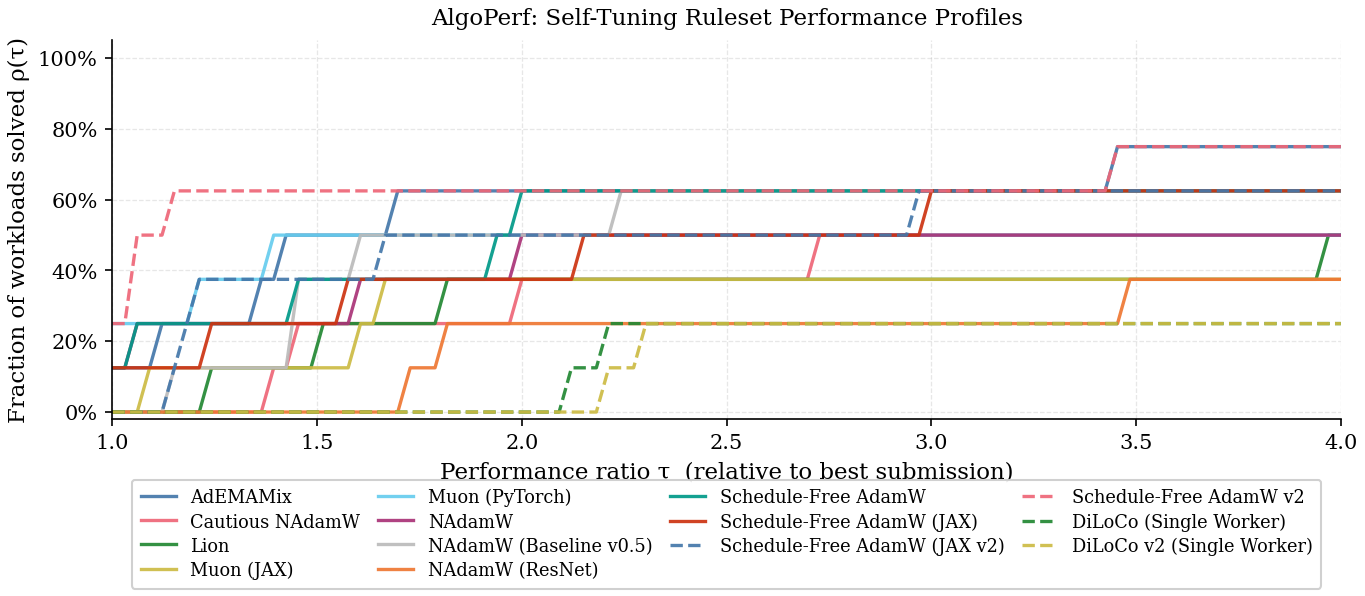


--- Leaderboard Scores ---


/tmp/ipykernel_709114/3734530332.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  scores = np.trapz(df, x=df.columns)


,score
submission,
Schedule-Free AdamW v2,0.638889
AdEMAMix,0.583965
Schedule-Free AdamW,0.525253
NAdamW (Baseline v0.5),0.506944
Schedule-Free AdamW (JAX v2),0.495581
Muon (PyTorch),0.476010
Schedule-Free AdamW (JAX),0.462121
NAdamW,0.432449
Cautious NAdamW,0.353535


Saved to /home/kasimbeg/submissions_algorithms/scoring_artifacts/scores.csv


In [8]:
if not STRICT:
    print(
        'WARNING: STRICT=False relaxes criteria on held-out workloads, '
        'trial counts, and study counts. Scores may not match official '
        'competition scoring. Set STRICT=True to enforce all rules.'
    )

if COMPUTE_PERFORMANCE_PROFILES:
    performance_profile_df = performance_profile.compute_performance_profiles(
        results,
        WORKLOAD_CONFIG,
        time_col='score',
        min_tau=MIN_TAU,
        max_tau=MAX_TAU,
        reference_submission_tag=None,
        num_points=NUM_POINTS,
        scale=SCALE,
        verbosity=0,
        self_tuning_ruleset=SELF_TUNING_RULESET,
        strict=STRICT,
        output_dir=OUTPUT_DIR,
    )

    # Save profile CSV so the Reload section (Section 7) always reflects the
    # current run rather than loading a stale file from a previous run.
    profile_csv = os.path.join(OUTPUT_DIR, 'performance_profile_score.csv')
    performance_profile_df.to_csv(profile_csv)

    # ── Styled plot ────────────────────────────────────────────────────────────
    fig, ax = plot_performance_profiles_styled(
        performance_profile_df,
        'score',
        scale=SCALE,
        save_dir=OUTPUT_DIR,
        title='AlgoPerf: Self-Tuning Ruleset Performance Profiles',
    )
    plt.show()

    # ── Scores table ──────────────────────────────────────────────────────────
    scores = compute_leaderboard_score(performance_profile_df)
    scores_path = os.path.join(OUTPUT_DIR, 'scores.csv')
    scores.to_csv(scores_path)

    print('\n--- Leaderboard Scores ---')
    display(scores.sort_values('score', ascending=False))
    print(f'Saved to {scores_path}')

## 6b. Time-to-Target Table
Shows the median time (seconds) each submission took to reach the validation target on each workload.\n`inf` means the target was not reached within the run.

In [9]:
ttt = pd.read_csv(os.path.join(OUTPUT_DIR, 'time_to_targets.csv'), index_col=0)

# Format: finite values as "Xs", inf as em-dash
def _fmt(v):
    if pd.isna(v) or v == float('inf'):
        return r'\textemdash{}'
    return f'{v:,.0f}s'

ttt_display = ttt.map(_fmt)
ttt_display.index.name = 'Submission'

print('--- Time to Target (seconds) ---')
display(ttt_display)

# ── Workload column → LaTeX macro ─────────────────────────────────────────────
_WL_MACRO = {
    'criteo1tb':              r'\criteo',
    'fastmri':                r'\fastmri',
    'finewebedu_lm':          r'\finewebedu',
    'imagenet_resnet':        r'\resnet',
    'imagenet_vit':           r'\vit',
    'librispeech_conformer':  r'\conformer',
    'librispeech_deepspeech': r'\deepspeech',
    'ogbg':                   r'\ogbg',
    'wmt':                    r'\wmt',
}

workloads  = list(ttt.columns)
col_spec   = 'l' + 'r' * len(workloads)
wl_headers = ' & '.join(_WL_MACRO.get(w, w) for w in workloads)

rows = []
for name, row in ttt_display.iterrows():
    rows.append('      ' + name + ' & ' + ' & '.join(str(v) for v in row) + r' \\')

latex = '\n'.join([
    r'\begin{table}[htbp]',
    r'  \centering',
    r'  \caption{Time to target (seconds). \textemdash{} = target not reached.}',
    r'  \label{tab:time_to_target}',
    r'  \resizebox{\textwidth}{!}{%',
    r'  \begin{tabular}{' + col_spec + '}',
    r'    \toprule',
    r'    Submission & ' + wl_headers + r' \\',
    r'    \midrule',
    *rows,
    r'    \bottomrule',
    r'  \end{tabular}%',
    r'  }',
    r'\end{table}',
])

ttt_latex_path = os.path.join(OUTPUT_DIR, 'time_to_target_table.tex')
with open(ttt_latex_path, 'w') as f:
    f.write(latex)
print(f'\nLaTeX saved → {ttt_latex_path}')


--- Time to Target (seconds) ---


,criteo1tb,fastmri,finewebedu_lm,imagenet_resnet,imagenet_vit,librispeech_conformer,librispeech_deepspeech,ogbg,wmt
Submission,,,,,,,,,
AdEMAMix,"7,839s","1,518s","18,026s",\textemdash{},\textemdash{},"48,895s",\textemdash{},"6,330s","17,400s"
Cautious NAdamW,\textemdash{},"1,608s","25,739s",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"4,993s","14,232s"
Lion,\textemdash{},"1,394s","23,172s",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"7,224s","15,476s"
Muon (JAX),\textemdash{},"1,870s","20,594s",\textemdash{},"77,163s",\textemdash{},\textemdash{},\textemdash{},\textemdash{}
Muon (PyTorch),"7,142s",\textemdash{},"15,472s",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"1,833s","14,215s"
NAdamW,"7,493s","1,801s","25,734s",\textemdash{},"72,016s",\textemdash{},\textemdash{},\textemdash{},\textemdash{}
NAdamW (Baseline v0.5),"8,206s","1,621s","20,590s",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"4,090s","14,866s"
NAdamW (ResNet),\textemdash{},"1,921s","23,163s",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"6,350s",\textemdash{}
Schedule-Free AdamW,"10,338s","1,189s",\textemdash{},\textemdash{},\textemdash{},\textemdash{},"40,463s","3,640s","19,958s"



LaTeX saved → /home/kasimbeg/submissions_algorithms/scoring_artifacts/time_to_target_table.tex


## 7. LaTeX Tables
Generates a ready-to-paste LaTeX table of leaderboard scores, sorted best-first.\
nRun after Section 6.

In [10]:
def scores_to_latex(scores_df, caption='AlgoPerf Self-Tuning Leaderboard', label='tab:scores'):
    """
    Render a leaderboard scores DataFrame as a LaTeX table.
    Submission names come from the DataFrame index (already pretty-named).
    Scores are formatted to 4 decimal places; best score is bolded.
    """
    df = scores_df.sort_values('score', ascending=False).copy()
    df['rank'] = range(1, len(df) + 1)

    best_score = df['score'].iloc[0]

    rows = []
    for rank, (name, row) in enumerate(df.iterrows(), start=1):
        score_str = f'{row["score"]:.4f}'
        if row['score'] == best_score:
            score_str = r'\textbf{' + score_str + '}'
        rows.append(f'    {rank} & {name} & {score_str} \\\\')

    body = '\n'.join(rows)

    latex = (
        r'\begin{table}[h]' + '\n'
        r'  \centering' + '\n'
        r'  \caption{' + caption + '}\n'
        r'  \label{' + label + '}\n'
        r'  \begin{tabular}{rlr}' + '\n'
        r'    \toprule' + '\n'
        r'    Rank & Submission & Score \\' + '\n'
        r'    \midrule' + '\n'
        + body + '\n'
        r'    \bottomrule' + '\n'
        r'  \end{tabular}' + '\n'
        r'\end{table}'
    )
    return latex


latex_table = scores_to_latex(scores)
print(latex_table)

latex_path = os.path.join(OUTPUT_DIR, 'scores_table.tex')
with open(latex_path, 'w') as f:
    f.write(latex_table)
print(f'\nSaved to {latex_path}')

\begin{table}[h]
  \centering
  \caption{AlgoPerf Self-Tuning Leaderboard}
  \label{tab:scores}
  \begin{tabular}{rlr}
    \toprule
    Rank & Submission & Score \\
    \midrule
    1 & Schedule-Free AdamW v2 & \textbf{0.6389} \\
    2 & AdEMAMix & 0.5840 \\
    3 & Schedule-Free AdamW & 0.5253 \\
    4 & NAdamW (Baseline v0.5) & 0.5069 \\
    5 & Schedule-Free AdamW (JAX v2) & 0.4956 \\
    6 & Muon (PyTorch) & 0.4760 \\
    7 & Schedule-Free AdamW (JAX) & 0.4621 \\
    8 & NAdamW & 0.4324 \\
    9 & Cautious NAdamW & 0.3535 \\
    10 & Muon (JAX) & 0.3201 \\
    11 & Lion & 0.3131 \\
    12 & NAdamW (ResNet) & 0.2090 \\
    13 & DiLoCo (Single Worker) & 0.1540 \\
    14 & DiLoCo v2 (Single Worker) & 0.1465 \\
    \bottomrule
  \end{tabular}
\end{table}

Saved to /home/kasimbeg/submissions_algorithms/scoring_artifacts/scores_table.tex


## 7. (Optional) Reload and Replot from Saved CSVs

If you already have a `performance_profile_score.csv` saved, you can reload and replot without re-running the full pipeline.

Saved → /home/kasimbeg/submissions_algorithms/scoring_artifacts/performance_profile_by_score.pdf / .png


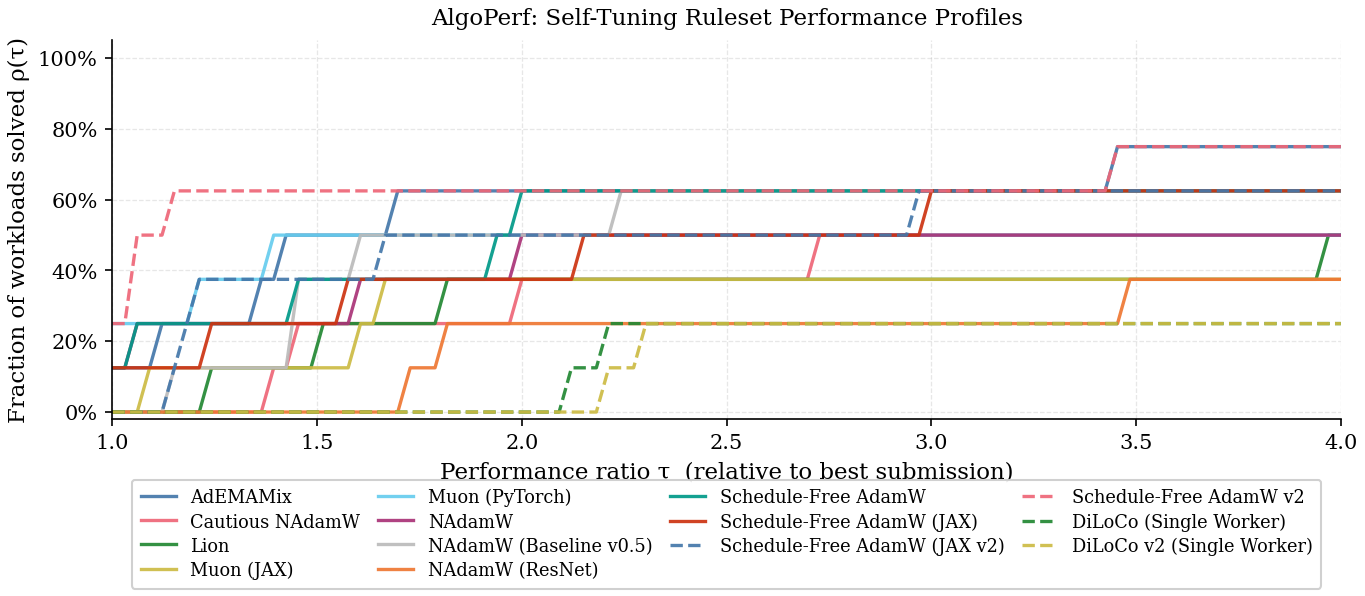

/tmp/ipykernel_2935401/3734530332.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  scores = np.trapz(df, x=df.columns)


,score
submission,
Schedule-Free AdamW v2,0.638889
AdEMAMix,0.583965
Schedule-Free AdamW,0.525253
NAdamW (Baseline v0.5),0.506944
Schedule-Free AdamW (JAX v2),0.495581
Muon (PyTorch),0.476010
Schedule-Free AdamW (JAX),0.462121
NAdamW,0.432449
Cautious NAdamW,0.353535


In [13]:
csv_file = os.path.join(OUTPUT_DIR, 'performance_profile_score.csv')

if os.path.exists(csv_file):
    reloaded_df = pd.read_csv(csv_file, index_col=0)
    reloaded_df.columns = reloaded_df.columns.astype(float)
    fig, ax = plot_performance_profiles_styled(
        reloaded_df,
        'score',
        save_dir=OUTPUT_DIR,
        title='AlgoPerf: Self-Tuning Ruleset Performance Profiles',
    )
    plt.show()
    display(compute_leaderboard_score(reloaded_df).sort_values('score', ascending=False))
else:
    print(f'No saved profile found at {csv_file}. Run Section 6 first.')

## 8. Step-Based Scoring: Step vs. Wall-Clock Efficiency

Re-scores every submission with the identical performance-profile machinery,
but using `global_step` (optimizer steps to target) as the time column instead
of wall-clock seconds. Same workload config, same $\tau$ range, same
denominator. Artifacts are written with a `_steps` suffix, plus:

- `steps_to_target_table.tex` — per-workload median steps to target
- `leaderboard_steps_table.tex` — wall-clock vs. step-based scores and ranks
- `wallclock_vs_steps.{pdf,png}` — scatter of the two benchmark scores

Caveat: submissions choose their own batch sizes, so step counts compare
optimizer updates, not examples seen; steps are not sample-normalized.


In [ ]:
# ── Step-based performance profiles and leaderboard scores ────────────────────
performance_profile_steps_df = performance_profile.compute_performance_profiles(
    results,
    WORKLOAD_CONFIG,
    time_col='global_step',
    min_tau=MIN_TAU,
    max_tau=MAX_TAU,
    reference_submission_tag=None,
    num_points=NUM_POINTS,
    scale=SCALE,
    verbosity=0,
    self_tuning_ruleset=SELF_TUNING_RULESET,
    strict=STRICT,
    output_dir=OUTPUT_DIR,          # writes time_to_targets_steps.csv
    artifact_suffix='_steps',
)
performance_profile_steps_df.to_csv(
    os.path.join(OUTPUT_DIR, 'performance_profile_global_step.csv')
)

fig, ax = plot_performance_profiles_styled(
    performance_profile_steps_df,
    'global_step',
    scale=SCALE,
    save_dir=OUTPUT_DIR,
    title='AlgoPerf: Self-Tuning Performance Profiles (steps to target)',
)
plt.show()

scores_steps = compute_leaderboard_score(performance_profile_steps_df)
scores_steps.to_csv(os.path.join(OUTPUT_DIR, 'scores_steps.csv'))
print('--- Step-based Leaderboard Scores ---')
display(scores_steps.sort_values('score', ascending=False))


In [ ]:
# ── Steps-to-target table (analog of the time-to-target table) ────────────────
stt = pd.read_csv(os.path.join(OUTPUT_DIR, 'time_to_targets_steps.csv'), index_col=0)

def _fmt_steps(v):
    if pd.isna(v) or v == float('inf'):
        return r'\textemdash{}'
    return f'{v:,.0f}'

stt_display = stt.map(_fmt_steps)
stt_display.index.name = 'Submission'
display(stt_display)

_stt_workloads = list(stt.columns)
_stt_col_spec  = 'l' + 'r' * len(_stt_workloads)
_stt_headers   = ' & '.join(_WL_MACRO.get(w, w) for w in _stt_workloads)

_stt_rows = []
for name, row in stt_display.iterrows():
    _stt_rows.append('      ' + name + ' & ' + ' & '.join(str(v) for v in row) + r' \\')

stt_latex = '\n'.join([
    r'\begin{table}[htbp]',
    r'  \centering',
    r'  \caption{Median number of optimizer steps to reach the validation target.'
    r' \textemdash{} = target not reached. Submissions choose their own batch'
    r' sizes, so step counts compare optimizer updates, not examples seen.}',
    r'  \label{tab:steps_to_target}',
    r'  \resizebox{\textwidth}{!}{%',
    r'  \begin{tabular}{' + _stt_col_spec + '}',
    r'    \toprule',
    r'    Submission & ' + _stt_headers + r' \\',
    r'    \midrule',
    *_stt_rows,
    r'    \bottomrule',
    r'  \end{tabular}%',
    r'  }',
    r'\end{table}',
])

with open(os.path.join(OUTPUT_DIR, 'steps_to_target_table.tex'), 'w') as f:
    f.write(stt_latex)
print('LaTeX saved -> steps_to_target_table.tex')


In [ ]:
# ── Scatter: wall-clock score vs. step-based score ────────────────────────────
# One marker per algorithm family, validated colorblind-safe colors cycling
# within each family; dark marker edges keep light fills legible on white.
# Print-true sizing: the paper includes this at \textwidth = 6.5in, square
# plot left, family-grouped legend right, real paper point sizes throughout.
_SC_COLORS = ['#3D6FC4', '#EE6677', '#228833', '#AA3377',
              '#EE7733', '#009988', '#CC3311']

# One marker per algorithm family, colors cycling within the family; legend
# entries are grouped so family members sit next to each other.
_FAMILIES = [
    ('o', ['Schedule-Free AdamW v2', 'Schedule-Free AdamW',
           'Schedule-Free AdamW (JAX)', 'Schedule-Free AdamW (JAX v2)']),
    ('s', ['NAdamW', 'NAdamW (Baseline v0.5)', 'NAdamW (ResNet)',
           'Cautious NAdamW']),
    ('D', ['Muon (PyTorch)', 'Muon (JAX)']),
    ('^', ['DiLoCo (Single Worker)', 'DiLoCo v2 (Single Worker)']),
    ('P', ['AdEMAMix']),
    ('X', ['Lion']),
]

# Print-true sizing: included at \textwidth = 6.5in; square plot on the left,
# grouped legend on the right; real paper point sizes throughout.
fig, ax = plt.subplots(figsize=(6.5, 3.8))

lims = (0.10, 0.60)
ax.plot(lims, lims, linestyle='--', color='#999999', linewidth=0.9, zorder=1)
ax.text(0.125, 0.585, 'wall-clock advantage',
        ha='left', va='top', fontsize=7.5, style='italic', color='#777777')
ax.text(0.585, 0.125, 'step advantage',
        ha='right', va='bottom', fontsize=7.5, style='italic', color='#777777')

for marker, members in _FAMILIES:
    for j, name in enumerate(members):
        row = cmp.loc[name]
        ax.scatter(
            row.steps, row.wallclock,
            color=_SC_COLORS[(4 if marker in 'PX' else j) % len(_SC_COLORS)],
            marker=marker, s=42, linewidths=0.5, edgecolors='#333333',
            zorder=3, label=name,
        )

_annotate = {
    'Schedule-Free AdamW v2': (-7, -4, 'right'),
    'AdEMAMix':               (-8, -6, 'right'),
    'Muon (JAX)':             (7, -3, 'left'),
    'DiLoCo (Single Worker)': (-4, 8, 'left'),
}
for name, (dx, dy, ha) in _annotate.items():
    row = cmp.loc[name]
    label = 'DiLoCo v1/v2' if name.startswith('DiLoCo') else name
    ax.annotate(label, (row.steps, row.wallclock), xytext=(dx, dy),
                textcoords='offset points', fontsize=7.5, ha=ha,
                color='#333333')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.tick_params(labelsize=9)
ax.set_xlabel('Step-based benchmark score', fontsize=10)
ax.set_ylabel('Wall-clock benchmark score', fontsize=10)

ax.legend(
    loc='center left', bbox_to_anchor=(1.04, 0.5), ncol=1, fontsize=8,
    borderaxespad=0, frameon=True, framealpha=0.92, edgecolor='#cccccc',
    handlelength=1.0, columnspacing=1.0, labelspacing=0.45, borderpad=0.6,
)
fig.subplots_adjust(left=0.08, right=0.66, top=0.97, bottom=0.13)

for ext in ('pdf', 'png'):
    fig.savefig(os.path.join(OUTPUT_DIR, f'wallclock_vs_steps.{ext}'), format=ext, dpi=300)
print('Saved -> wallclock_vs_steps.pdf / .png')
plt.show()


In [ ]:
# ── Scatter: wall-clock score vs. step-based score ────────────────────────────
# 7 colorblind-safe colors x 2 marker shapes = 14 distinct (color, marker)
# identities; dark marker edges keep light fills legible on white.
_SC_COLORS  = ['#3D6FC4', '#EE6677', '#228833', '#AA3377',
               '#EE7733', '#009988', '#CC3311']
_SC_MARKERS = ['o', 's']

fig, ax = plt.subplots(figsize=(7.0, 7.6))

lims = (0.10, 0.60)
ax.plot(lims, lims, linestyle='--', color='#999999', linewidth=1.0, zorder=1)
ax.text(0.135, 0.575, 'wall-clock advantage\n(cheap, fast steps)',
        ha='left', va='top', fontsize=8.5, style='italic', color='#777777')
ax.text(0.575, 0.135, 'step advantage\n(expensive steps)',
        ha='right', va='bottom', fontsize=8.5, style='italic', color='#777777')

for i, (name, row) in enumerate(cmp.iterrows()):
    ax.scatter(
        row.steps, row.wallclock,
        color=_SC_COLORS[i % len(_SC_COLORS)],
        marker=_SC_MARKERS[i // len(_SC_COLORS)],
        s=58, linewidths=0.6, edgecolors='#333333', zorder=3, label=name,
    )

_annotate = {
    'Schedule-Free AdamW v2':    (-8, 2, 'right'),
    'AdEMAMix':                  (8, 3, 'left'),
    'Muon (JAX)':                (8, -3, 'left'),
    'NAdamW':                    (8, 1, 'left'),
    'DiLoCo (Single Worker)':    (-2, 9, 'left'),
    'DiLoCo v2 (Single Worker)': (5, -12, 'left'),
}
for name, (dx, dy, ha) in _annotate.items():
    row = cmp.loc[name]
    ax.annotate(name, (row.steps, row.wallclock), xytext=(dx, dy),
                textcoords='offset points', fontsize=8, ha=ha,
                color='#333333')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.set_xlabel('Step-based benchmark score')
ax.set_ylabel('Wall-clock benchmark score')
ax.set_title('Wall-clock vs. step-based benchmark scores', pad=8)

n = len(cmp)
ncol = 3
ax.legend(
    loc='upper center', bbox_to_anchor=(0.5, -0.11), ncol=ncol,
    borderaxespad=0, frameon=True, handlelength=1.0, columnspacing=0.9,
    labelspacing=0.35,
)
fig.subplots_adjust(left=0.10, right=0.97, top=0.94, bottom=0.24)

for ext in ('pdf', 'png'):
    fig.savefig(os.path.join(OUTPUT_DIR, f'wallclock_vs_steps.{ext}'),
                format=ext, dpi=300)
print('Saved -> wallclock_vs_steps.pdf / .png')
plt.show()
